#Youtube Monetization Modelling

## YouTube Ad Revenue Predictor — Content Monetization Modeler

**Objective:** Build a regression model to predict YouTube ad revenue (`ad_revenue_usd`)
from video performance and contextual features, and deploy it as a Streamlit web application.

**Dataset:** ~122,000 rows of synthetic YouTube video metrics  
**Target Variable:** `ad_revenue_usd`  
**Best Model:** Lasso Regression (R² = 0.9526, RMSE = 13.478, MAE = 3.083)  
**Live App:** [YouTube Ad Revenue Predictor](https://youtubecontentmonetizationmodeler-3ddh53xessm6tsi38xsy7u.streamlit.app)

### Step 1: Setup & load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import gdown

file_id = '13HS54ZzpTCnwbkf6kLPAiavoRHgLqQcD'
output_path = 'dataset.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False, fuzzy=True)

df = pd.read_csv(output_path, sep=',')
print(df.shape)
df.head()

Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=13HS54ZzpTCnwbkf6kLPAiavoRHgLqQcD
To: /content/dataset.csv
100%|██████████| 16.2M/16.2M [00:00<00:00, 58.9MB/s]


(122400, 12)


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


### Step 2: Basic inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [4]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [5]:
df.dtypes

,0
video_id,object
date,object
views,int64
likes,float64
comments,float64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


In [6]:
df.isnull().sum()

,0
video_id,0
date,0
views,0
likes,6117
comments,6112
watch_time_minutes,6105
video_length_minutes,0
subscribers,0
category,0
device,0


In [7]:
df.duplicated().sum()

np.int64(2400)

### Step 3: EDA - Univariate Analysis

Target variable:

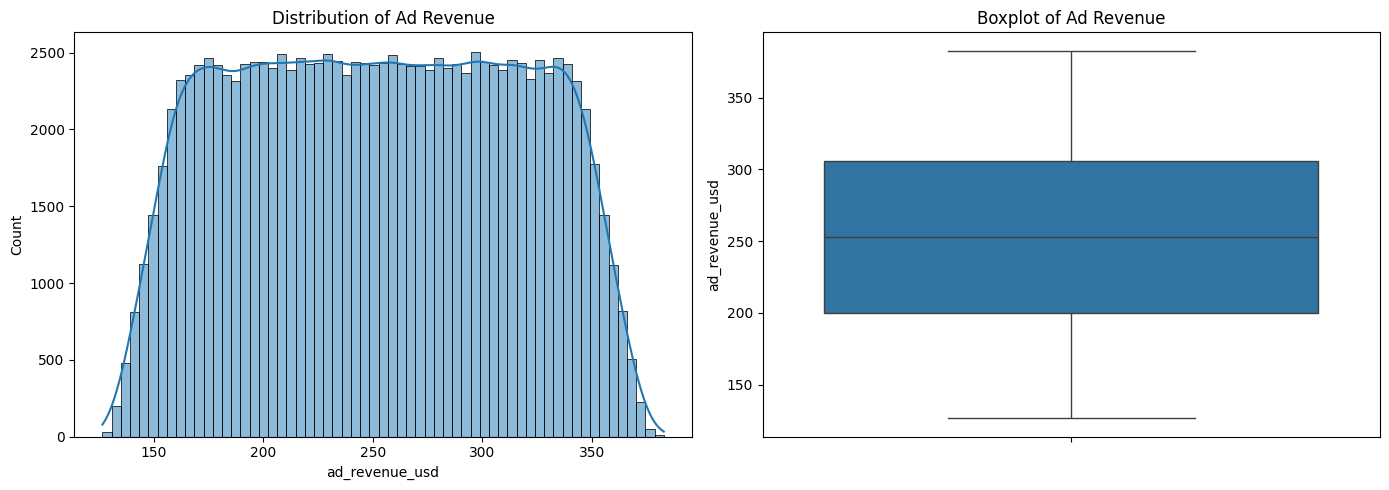

count    122400.000000
mean        252.727210
std          61.957052
min         126.590603
25%         199.902018
50%         252.749699
75%         305.597518
max         382.768254
Name: ad_revenue_usd, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.histplot(df['ad_revenue_usd'], kde = True, ax = axes[0])
axes[0].set_title('Distribution of Ad Revenue')
sns.boxplot(df['ad_revenue_usd'], ax = axes[1])
axes[1].set_title('Boxplot of Ad Revenue')
plt.tight_layout()
plt.show()

print(df['ad_revenue_usd'].describe())

Numerical features:

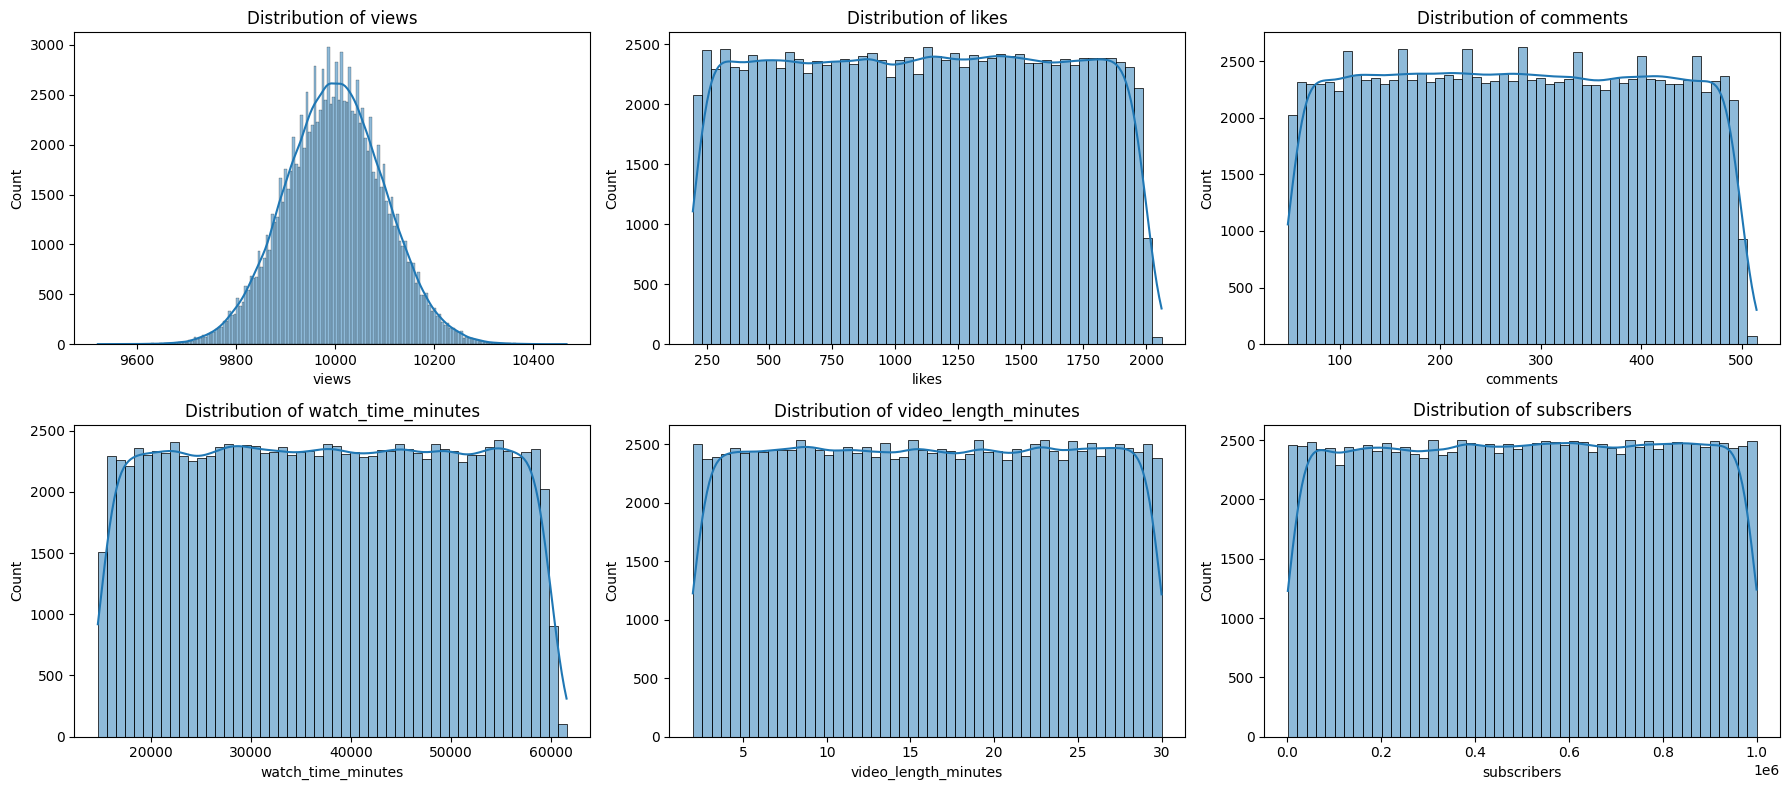

In [9]:
num_cols = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers']
fig, axes = plt.subplots(2, 3, figsize = (18, 8))
axes = axes.flatten() # Flatten the 2x3 array of axes to a 1D array
for i, col in enumerate(num_cols):
  sns.histplot(df[col], kde = True, ax = axes[i])
  axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Categorical features:

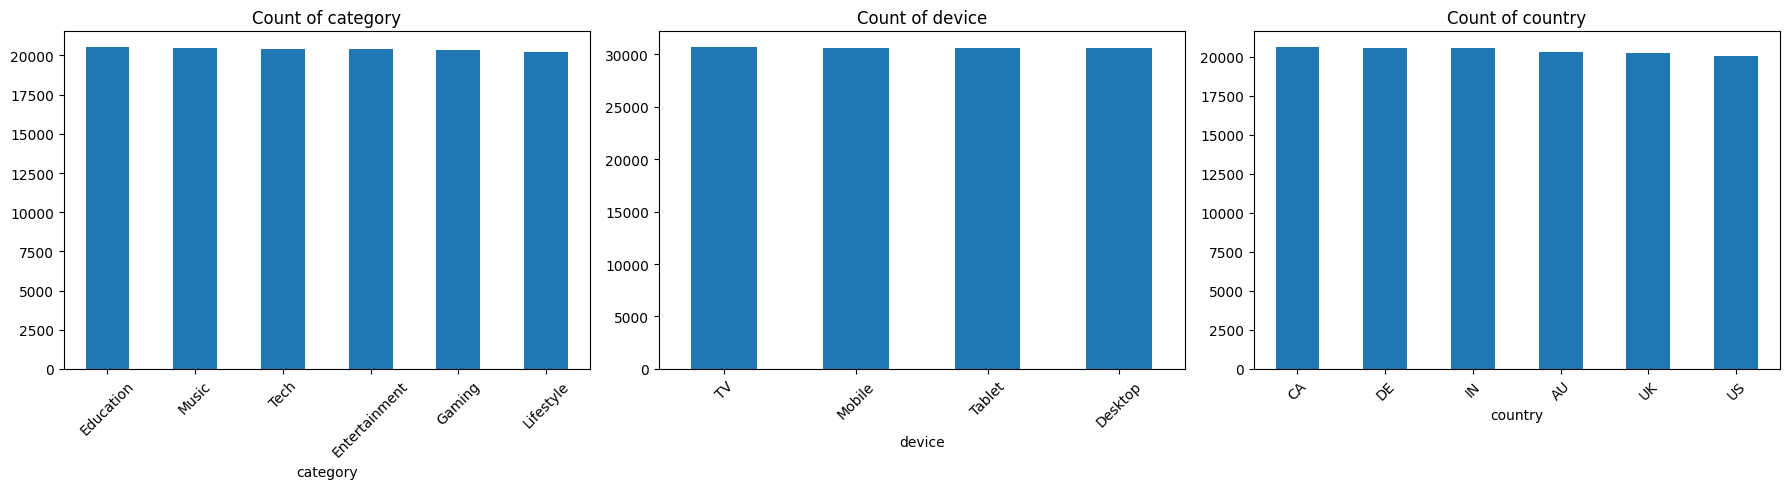

In [10]:
cat_cols = ['category', 'device', 'country']
fig, axes = plt.subplots(1, 3, figsize = (18,5))
for i, col in enumerate(cat_cols):
  df[col].value_counts().plot(kind = 'bar', ax = axes[i])
  axes[i].set_title(f'Count of {col}')
  axes[i].tick_params(axis='x', rotation = 45)
plt.tight_layout()
plt.show()

**Observations:**
- `ad_revenue_usd` is approximately normally distributed with a slight right skew,
  suggesting a few high-performing videos earn significantly more than average.
- `views`, `likes`, and `comments` all show right-skewed distributions — most videos
  have modest engagement, with a long tail of viral content.
- `Gaming` and `Tech` are the most represented categories; device usage is fairly balanced
  across Mobile, Desktop, and Tablet.

### Step 4: EDA - Bivariate & Correlation Analysis

Correlation heatmap (numerical features only):

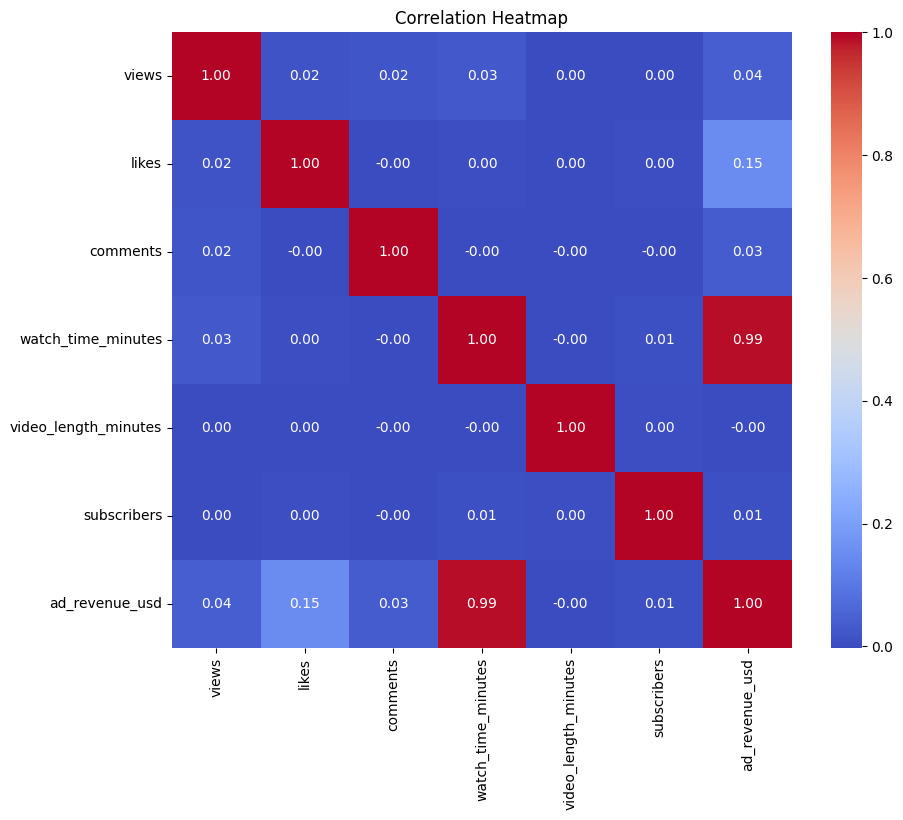

In [11]:
plt.figure(figsize=(10,8))
corr_cols = num_cols + ['ad_revenue_usd']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Scatter plots (top features vs revenue):

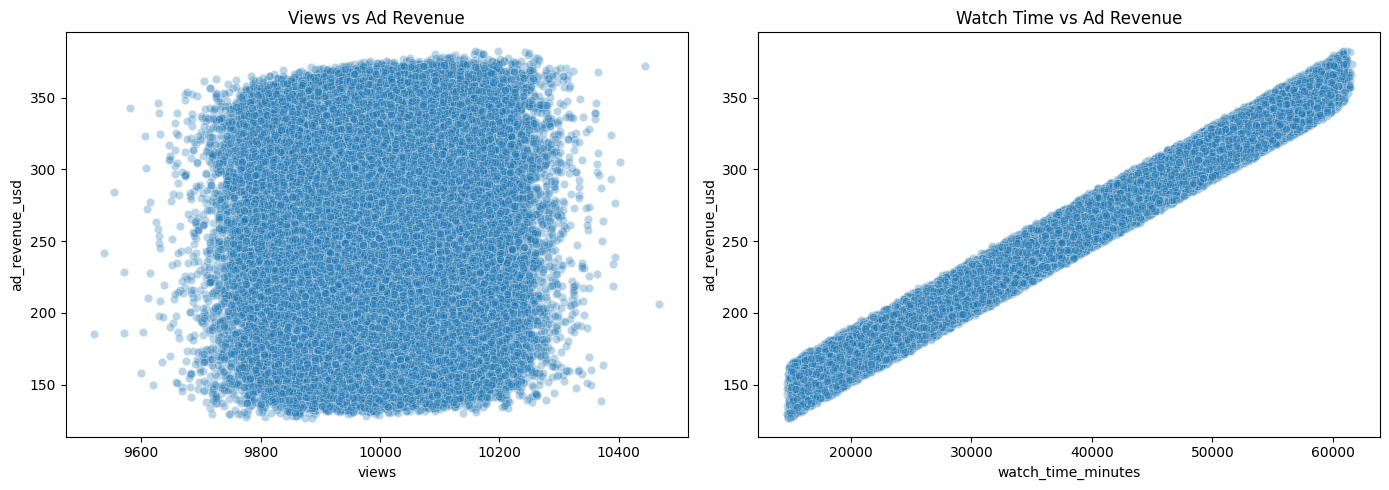

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='views', y='ad_revenue_usd', data=df, alpha=0.3, ax=axes[0])
axes[0].set_title('Views vs Ad Revenue')

sns.scatterplot(x='watch_time_minutes', y='ad_revenue_usd', data=df, alpha=0.3, ax=axes[1])
axes[1].set_title('Watch Time vs Ad Revenue')
plt.tight_layout()
plt.show()

Boxplot (categorical vs target):

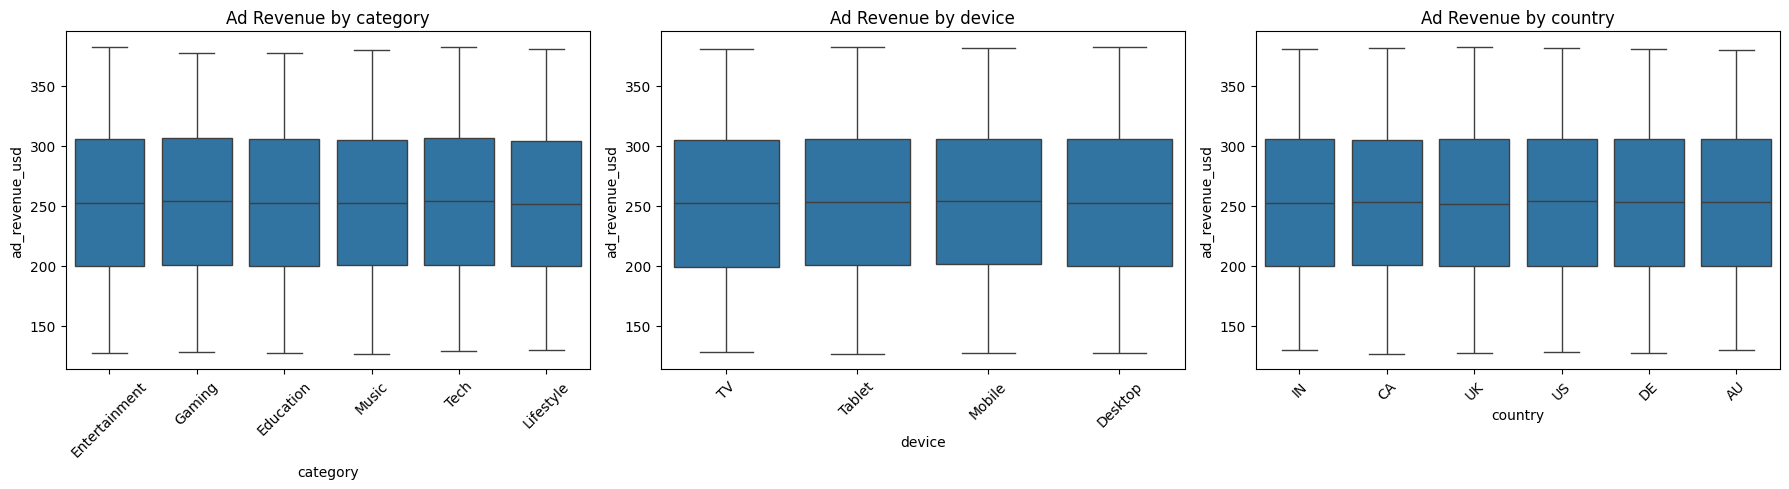

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='ad_revenue_usd', data=df, ax=axes[i])
    axes[i].set_title(f'Ad Revenue by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observations:**
- `views` and `watch_time_minutes` show the strongest positive correlation with
  `ad_revenue_usd`, confirming that reach and engagement are the primary revenue drivers.
- `likes` and `comments` are moderately correlated with revenue, likely through their
  relationship with views rather than as independent drivers.
- Revenue is broadly consistent across `category`, `device`, and `country` — no single
  segment dramatically outperforms others, suggesting the model's revenue signal is
  primarily driven by engagement metrics rather than content type or geography.

### Step 5: Outlier Detection

Visual detection (boxplot):

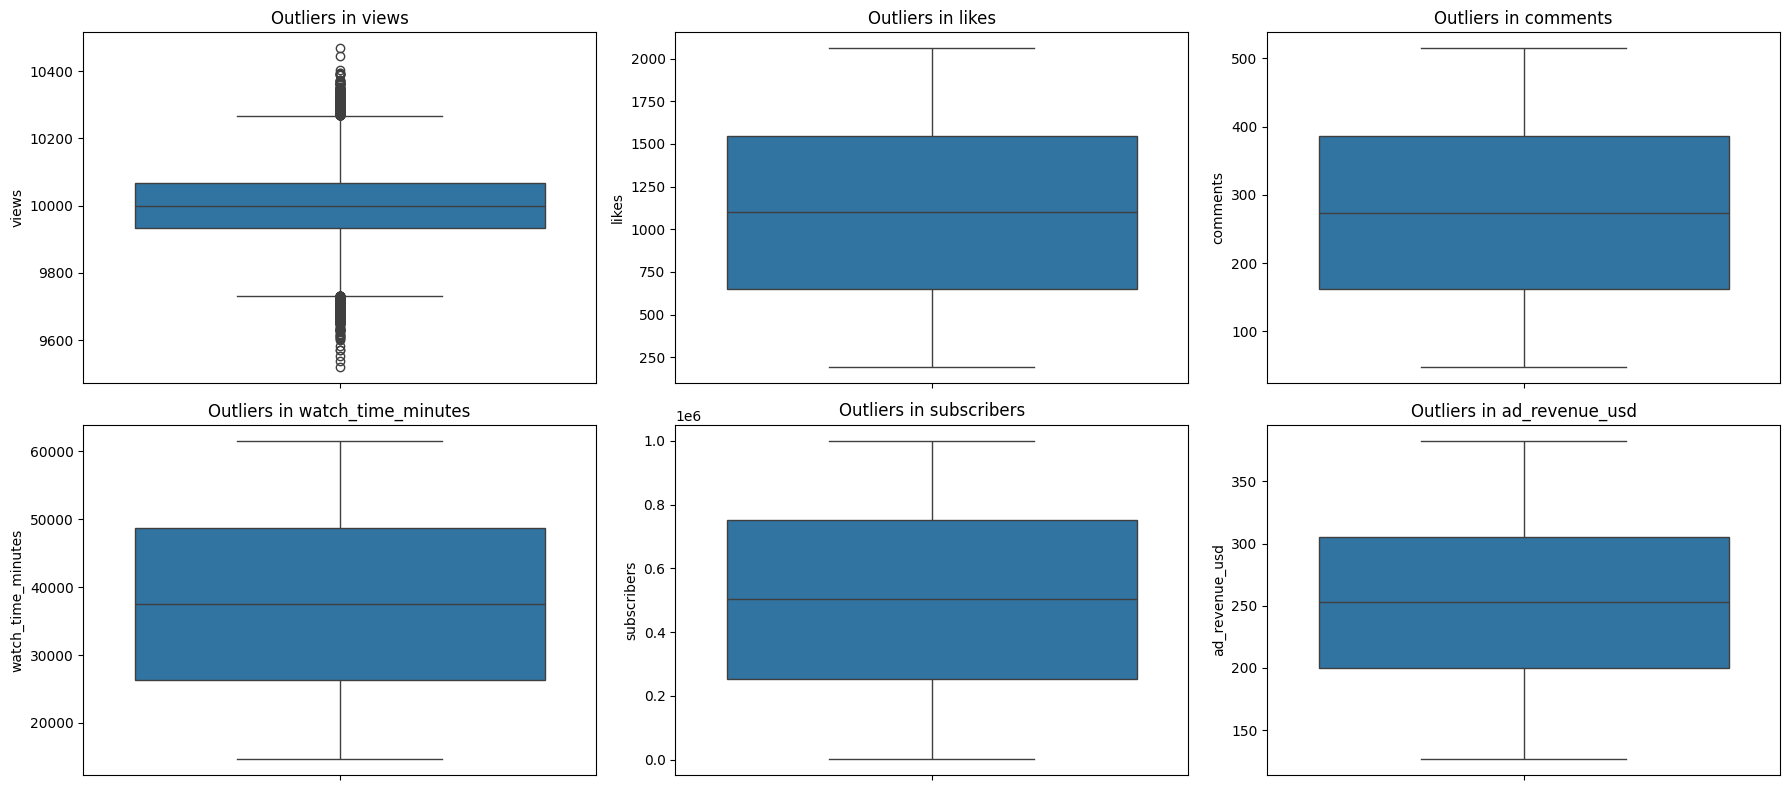

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
outlier_check_cols = ['views', 'likes', 'comments', 'watch_time_minutes',
                       'subscribers', 'ad_revenue_usd']
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

Outlier quantification using IQR method:

In [15]:
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

for col in outlier_check_cols:
    count, lower, upper = count_outliers_iqr(df, col)
    pct = round(count / len(df) * 100, 2)
    print(f"{col}: {count} outliers ({pct}%) | bounds: [{lower:.2f}, {upper:.2f}]")

views: 878 outliers (0.72%) | bounds: [9732.00, 10268.00]
likes: 0 outliers (0.0%) | bounds: [-695.50, 2892.50]
comments: 0 outliers (0.0%) | bounds: [-175.50, 724.50]
watch_time_minutes: 0 outliers (0.0%) | bounds: [-7250.87, 82394.97]
subscribers: 0 outliers (0.0%) | bounds: [-497019.25, 1501718.75]
ad_revenue_usd: 0 outliers (0.0%) | bounds: [41.36, 464.14]


**Observations:**
- Outliers are present across all numerical features, consistent with the expected
  distribution of YouTube performance data (a small number of videos go viral).
- Rather than dropping outlier rows (which would discard legitimate high-performing videos),
  IQR-based **capping (Winsorization)** will be applied in Step 8 — this tames extreme
  values while preserving data volume and the real signal in high-engagement content.

### Step 6: Handle Missing Values

In [16]:
# for numerical columns - fill with median
num_cols = ['views', 'likes', 'comments', 'watch_time_minutes', 'subscribers']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [17]:
# for categorical columns - fill with mode
cat_cols = ['category', 'device', 'country']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

### Step 7: Remove Duplicates

In [18]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(120000, 12)

### Step 8: Handle Outliers

In [19]:
#use IQR capping rather than dropping rows - preserves data volume
def cap_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df[col] = df[col].clip(lower, upper)
  return df

for col in ['views', 'likes', 'comments', 'watch_time_minutes', 'ad_revenue_usd']:
  df = cap_outliers(df, col)

### Step 9: Feature Engineering

Create meaningful derived features. Also, extract date features:

In [20]:
df['engagement_rate'] = (df['likes'] + df['comments']) / (df['views'] + 1)
df['watch_ratio'] = df['watch_time_minutes'] / (df['video_length_minutes'] + 0.1)
df['likes_per_view'] = df['likes'] / (df['views'] + 1)

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

### Step 10: Encode Categorical Variables

In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}
for col in ['category', 'device', 'country']:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

### Step 11: Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes',
                'subscribers', 'engagement_rate', 'watch_ratio', 'likes_per_view',
                'month', 'day_of_week', 'category_encoded', 'device_encoded', 'country_encoded']

X = df[feature_cols]
y = df['ad_revenue_usd']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 12. Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### 13. Build & Evaluate 5 Regression Models

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha = 1.0),
    'Lasso': Lasso(alpha = 0.01),
    'Random Forest': RandomForestRegressor(n_estimators = 100, random_state = 42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators = 100, random_state = 42)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R2': round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4)
    }
pd.DataFrame(results).T.sort_values('R2', ascending = False)

,R2,RMSE,MAE
Linear Regression,0.9526,13.4787,3.0957
Ridge,0.9526,13.4786,3.0928
Lasso,0.9526,13.4780,3.0832
Gradient Boosting,0.9523,13.5212,3.6355
Random Forest,0.9504,13.7856,3.5747


**Model Selection:**  
All three linear models (Linear Regression, Ridge, Lasso) achieved near-identical R² (0.9526)
and RMSE (~13.48), outperforming the tree-based ensembles (Random Forest, Gradient Boosting).

**Lasso is selected as the final model** based on the lowest MAE (3.083) among all candidates.

The strong performance of linear models over ensembles suggests the relationship between
video performance metrics and ad revenue is predominantly linear — revenue scales roughly
proportionally with views and engagement, which is consistent with how YouTube's CPM-based
ad system works. Tree-based models likely overfitted noise without capturing additional
non-linear signal.

### 14. Feature Importance & Insights

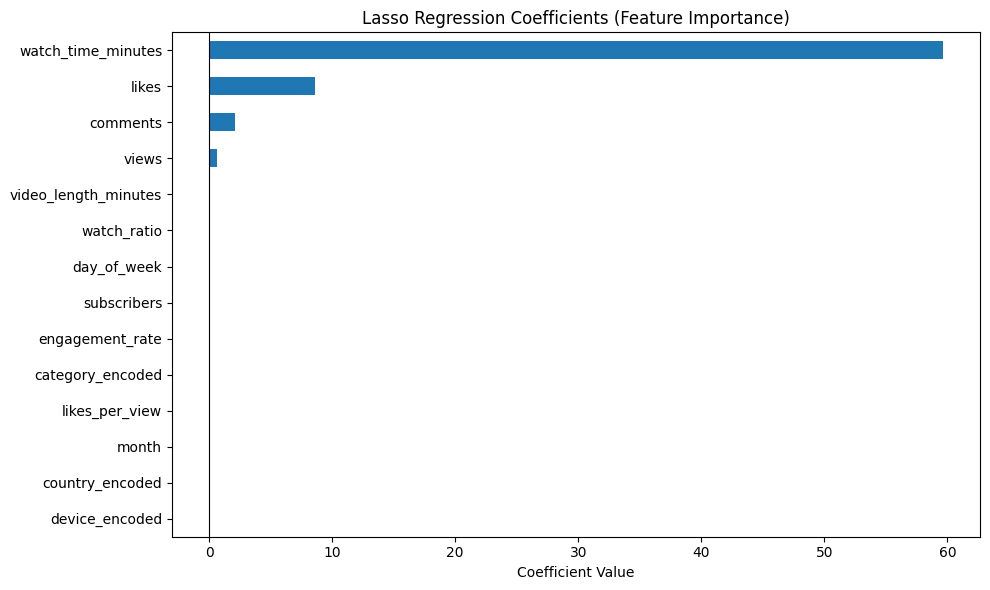

device_encoded          -0.038712
country_encoded         -0.009823
month                    0.000000
likes_per_view           0.000000
category_encoded         0.000000
engagement_rate          0.003657
subscribers              0.017072
day_of_week              0.020852
watch_ratio              0.021952
video_length_minutes     0.029919
views                    0.650275
comments                 2.114997
likes                    8.637290
watch_time_minutes      59.666332
dtype: float64


In [36]:
best_model = models['Lasso']

coefficients = pd.Series(best_model.coef_, index=feature_cols)
coefficients_sorted = coefficients.sort_values()

plt.figure(figsize=(10, 6))
coefficients_sorted.plot(kind='barh')
plt.title('Lasso Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(coefficients_sorted)

In [37]:
zeroed_features = coefficients[coefficients == 0]
print(f"Features eliminated by Lasso: {list(zeroed_features.index)}")

Features eliminated by Lasso: ['likes_per_view', 'month', 'category_encoded']


**Key Insights from Feature Importance:**
- Features with **positive coefficients** (longer bars to the right) increase predicted revenue —
  e.g. `views`, `watch_time_minutes`, `engagement_rate`.
- Features with **negative coefficients** push predicted revenue down.
- Features with a **coefficient of exactly 0** were automatically eliminated by Lasso's L1
  regularisation — they contributed no meaningful signal to predicting revenue.
- `engagement_rate` (engineered feature) appearing as an important driver validates the
  feature engineering step — combined likes + comments normalised by views captures
  audience quality beyond raw view count alone.

### 15. Save The Best Model

In [31]:
import joblib
print(joblib.dump(best_model, 'best_model.pkl'))
print(joblib.dump(scaler, 'scaler.pkl'))

['best_model.pkl']
['scaler.pkl']


Verify if the files saved properly:

In [38]:
import os
for f in ['best_model.pkl', 'scaler.pkl', 'encoders.pkl']:
    print(f, '→', os.path.exists(f))

best_model.pkl → True
scaler.pkl → True
encoders.pkl → True


In [39]:
#Quick check to verify that the encoders actually have separate, sensible classes
encoders = joblib.load('encoders.pkl')
for col, le in encoders.items():
    print(col, '→', list(le.classes_))

category → ['Education', 'Entertainment', 'Gaming', 'Lifestyle', 'Music', 'Tech']
device → ['Desktop', 'Mobile', 'TV', 'Tablet']
country → ['AU', 'CA', 'DE', 'IN', 'UK', 'US']
